<a href="https://colab.research.google.com/github/quarcs-lab/project2025s-py/blob/master/notebooks/c02_regional_convergence_sc.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" /></a>

This notebook examines absolute $\beta$-convergence in nighttime luminosity across 520 Indian districts (1996--2010). We regress per capita luminosity growth on initial luminosity levels and visualize the relationship in an annotated scatterplot. This analysis corresponds to the first set of results discussed in the main manuscript.

## Setup

In [ ]:
# Google Colab: install packages not included in the default environment
try:
    import google.colab
    !pip install statsmodels seaborn -q
except ImportError:
    pass  # Local environment — packages already installed

In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

## Data

We use district-level radiance-calibrated nighttime lights data from the DMSP-OLS satellites, covering 520 districts.

In [ ]:
# Load dataset (local copy first, else download from GitHub)
import os
import urllib.request

fname = "india520.dta"
url = "https://raw.githubusercontent.com/quarcs-lab/project2025s-py/master/data/" + fname
local = os.path.join("..", "data", fname)
path = local if os.path.exists(local) else fname
if path == fname and not os.path.exists(fname):
    urllib.request.urlretrieve(url, fname)
data = pd.read_stata(path)
print("Districts: {}".format(len(data)))

Districts: 520


## Convergence regression

A negative slope on initial luminosity indicates $\beta$-convergence: districts with lower initial luminosity grew faster over the period.

In [ ]:
# Basic OLS Regression
model1 = smf.ols("light_growth96_10rcr_cap ~ log_light96_rcr_cap", data=data).fit()
print(model1.summary())

                               OLS Regression Results                               
Dep. Variable:     light_growth96_10rcr_cap   R-squared:                       0.255
Model:                                  OLS   Adj. R-squared:                  0.253
Method:                       Least Squares   F-statistic:                     177.0
Date:                      Sat, 20 Jun 2026   Prob (F-statistic):           5.89e-35
Time:                              18:28:27   Log-Likelihood:                 974.41
No. Observations:                       520   AIC:                            -1945.
Df Residuals:                           518   BIC:                            -1936.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [ ]:
# Compute regression model for scatterplot annotation
model = smf.ols("light_growth96_10rcr_cap ~ log_light96_rcr_cap", data=data).fit()
slope = round(model.params["log_light96_rcr_cap"], 3)
rsq   = round(model.rsquared, 3)

The $\beta$ coefficient implies an annual **speed of convergence** $\lambda = -\ln(1 + \beta T)/T$ (Barro & Sala-i-Martin), where $T = 14$ years (1996--2010) and the dependent variable is the average annual growth rate, together with a **half-life** $\ln(2)/\lambda$ (the time to close half the gap to the steady state).

In [ ]:
# Implied annual speed of convergence and half-life (Barro & Sala-i-Martin)
T = 14  # 1996-2010; dependent variable is the average annual growth rate
beta = model.params["log_light96_rcr_cap"]
speed = -np.log(1 + beta * T) / T   # annual convergence speed (lambda)
half_life = np.log(2) / speed       # years to close half the gap
print("Convergence coefficient (beta): {:.4f}".format(beta))
print("Annual speed of convergence:    {:.2%}".format(speed))
print("Implied half-life:              {:.1f} years".format(half_life))

Convergence coefficient (beta): -0.0199
Annual speed of convergence:    2.33%
Implied half-life:              29.7 years


## Convergence scatterplot

The scatterplot below visualizes the convergence relationship. Outlier districts are labeled to highlight cases that deviate notably from the overall trend---either bright districts that declined or dim districts that grew unusually fast.

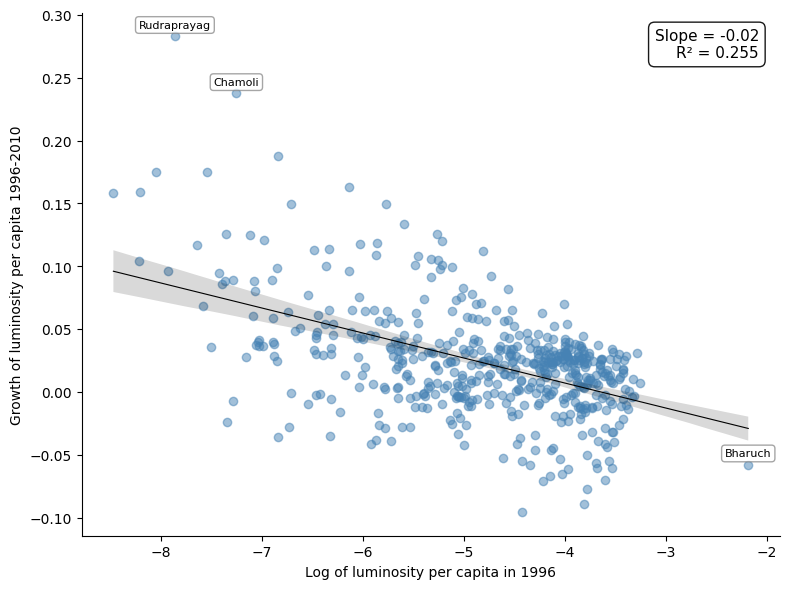

In [ ]:
#| label: fig-convergence
#| fig-cap: "Regional luminosity convergence across districts in India <br> Notes: Each point represents one of the 520 districts. The regression line shows the estimated beta-convergence relationship. Outlier districts are labeled. <br> Source: Data from Chanda and Kabiraj (2020). See [Regional convergence](notebooks/c02_regional_convergence_sc.ipynb) notebook for source code."

# Identify outlier districts for labeling
mask = (
    ((data["log_light96_rcr_cap"] > -3) & (data["light_growth96_10rcr_cap"] < 0))
    | ((data["log_light96_rcr_cap"] < -7) & (data["light_growth96_10rcr_cap"] > 0.2))
)
outliers = data[mask]

# Annotated scatterplot
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=data,
    x="log_light96_rcr_cap",
    y="light_growth96_10rcr_cap",
    ci=95,
    scatter_kws={"alpha": 0.5, "color": "steelblue"},
    line_kws={"color": "black", "linewidth": 0.8},
    ax=ax,
)

# Label outlier districts
for _, r in outliers.iterrows():
    ax.annotate(
        r["district"],
        xy=(r["log_light96_rcr_cap"], r["light_growth96_10rcr_cap"]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
    )

# Slope / R-squared annotation box (top-right corner)
annotation = "Slope = {}\nR² = {}".format(slope, rsq)
ax.annotate(
    annotation,
    xy=(0.97, 0.97),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9),
)

ax.set_xlabel("Log of luminosity per capita in 1996")
ax.set_ylabel("Growth of luminosity per capita 1996-2010")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()